In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString
import scipy.special as sc
from scipy.stats import crystalball

In [3]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][1]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    O_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [4]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_31949/3028205152.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_31949/553640031.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_31949/553640031.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [11]:
def NormCrystalGuassianStep(x,mu,sigma,alpha, n, f, p1,p2, d, E0, E1):
    Ec = (E1+E0)/2
    DE = (E1-E0)/2
    
    norm_poly = 2*DE+(2/3)*p2*DE**3
    poly = (1+p1*(x-Ec)+p2*(x-Ec)**2)/norm_poly
    
    step_norm_const = ((mu-E0)*special.erfc((E0-mu)/np.sqrt(2*np.pi*sigma**2))+(E1-mu)*special.erfc((E1-mu)/np.sqrt(2*np.pi*sigma**2))+np.sqrt(2*sigma**2)*(np.exp(-(mu-E0)**2/(2*np.pi*sigma**2))-np.exp(-(mu-E1)**2/(2*np.pi*sigma**2))))
    crystal = crystalball.pdf(x, beta=alpha, m=n, loc=mu, scale=sigma)
    step_function = special.erfc((x-mu)/np.sqrt(2*np.pi*sigma**2))
    
    return (1-f-d)*crystal+f*poly+(d*step_function)/step_norm_const

def NegLogLCrystalStep(params,data):
    mu,sigma,alpha, n, f, p1,p2, d= params
    E0 = min(data)
    E1 = max(data)
    x = NormCrystalGuassianStep(data,mu,sigma,alpha, n, f, p1,p2, d, E0, E1)
    x = x[x > 0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLCrystalStepPoly(data, initial_params):
    result = minimize(NegLogLCrystalStep, initial_params, args=(data),
                      method='Nelder-Mead',bounds=[(0, None), (0, None), (0, None),  (0, 100),(0,1), (None, None), (None, None), (0,1)])
    return result.x

def Chi2(data, arr):
    mu,sigma,alpha, n, f, p1,p2, d = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num, range = [int(min(data)), int(max(data))])
    
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormCrystalGuassianStep(filtered_bin_centers,mu,sigma,alpha, n, f, p1,p2, d, E0, E1)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Graph(data, arr):
    mu,sigma,alpha, n, f, p1,p2, d= arr
    x_values = np.linspace(min(data), max(data), 1000)
    bin_num = int(max(data) - min(data))
    bin_width = (max(data) - min(data))/bin_num
    
    E0 = min(data)
    E1=max(data)
    
    fitted_pdf = NormCrystalGuassianStep(x_values,mu,sigma,alpha, n, f, p1,p2, d, min(data), max(data))*len(data)*bin_width
    step_norm_const = ((mu-E0)*special.erfc((E0-mu)/np.sqrt(2*np.pi*sigma**2))+(E1-mu)*special.erfc((E1-mu)/np.sqrt(2*np.pi*sigma**2))+np.sqrt(2*sigma**2)*(np.exp(-(mu-E0)**2/(2*np.pi*sigma**2))-np.exp(-(mu-E1)**2/(2*np.pi*sigma**2))))
    
    step_function = (d*special.erfc((x_values-mu)/np.sqrt(2*np.pi*sigma**2))/step_norm_const)*len(data)*bin_width
    
    Ec = (E1+E0)/2
    DE = (E1-E0)/2
    
    norm_poly = 2*DE+(2/3)*p2*DE**3
    poly = f*(1+p1*(x_values-Ec)+p2*(x_values-Ec)**2)/norm_poly*len(data)*bin_width
    
    crystal = (1-f-d)*crystalball.pdf(x_values, beta=alpha, m=n, loc=mu, scale=sigma)*len(data)*bin_width
    
    return x_values, fitted_pdf, crystal, poly, step_function

def Residual_Plot(data, arr):
    mu,sigma,alpha, n, f, p1,p2, d= arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormCrystalGuassianStep(filtered_bin_centers,mu,sigma,alpha, n, f, p1,p2, d, min(data), max(data))*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)


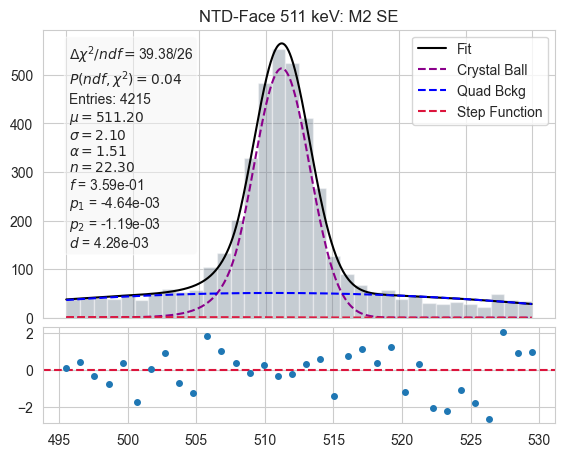

In [12]:
data = [i for i in NTD_511 if 495 <= i <= 530]
mu = 5.11206318e+02
sigma = 2.20254997e+00
alpha = 1.35
n = 8
p1 = 0.3
p2 = 0.05
d = 0.1
f = 0.1

params = [mu,sigma,alpha, n, f, p1,p2, d]

data_fits = MinimizeNegLogLCrystalStepPoly(data, params)

x_values, fitted_pdf, crystal, quad, step = Graph(np.asarray(data), data_fits)

chisq = Chi2(data, data_fits)

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(chisq, decimals=2)) +'/' +str(int(max(data) - min(data)) - 8, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(int(max(data) - min(data)) - 8, chisq), ),
    'Entries: ' + (str(len(data))),
    r'$\mu=%.2f$' % (data_fits[0], ),
    r'$\sigma=%.2f$' % (data_fits[1], ),
    r'$\alpha=%.2f$' % (data_fits[2], ),
    r'$n=%.2f$' % (data_fits[3], ),
    r'$f$ = ' + str(np.format_float_scientific(data_fits[4], precision = 2), ),
    r'$p_1$ = ' + str(np.format_float_scientific(data_fits[5], precision = 2), ),
    r'$p_2$ = ' + str(np.format_float_scientific(data_fits[6], precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(data_fits[7], precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fit', color='black')
ax.plot(x_values, crystal, label = 'Crystal Ball', linestyle='--', color='darkmagenta')
ax.plot(x_values, quad, label = 'Quad Bckg', linestyle='--', color='blue')
ax.plot(x_values, step, label='Step Function', linestyle = '--', color='crimson')

ax.hist(data, bins = int(max(data) - min(data)), color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('NTD-Face 511 keV: M2 SE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(data, data_fits)[0],Residual_Plot(data, data_fits)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

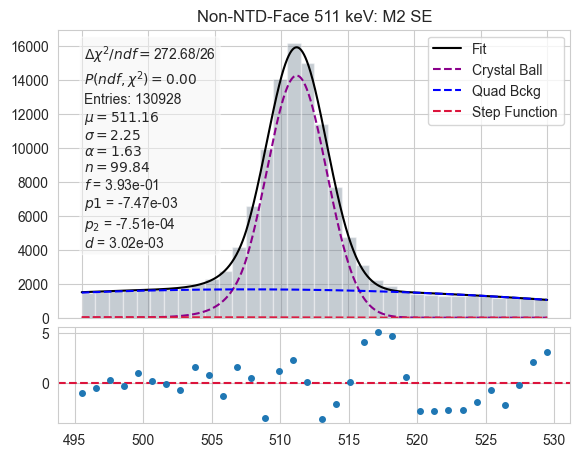

In [8]:
noNTD_2100, noNTD_511 = PrimarySecondarySplit(no_NTD_single)

dataNoNTD = [i for i in noNTD_511 if 495 <= i <= 530]

noNTDfits = MinimizeNegLogLCrystalStepPoly(dataNoNTD, data_fits)
# print(f"Fitted parameters: {fitted_params}")

x_values, fitted_pdf, crystal, quad, step = Graph(dataNoNTD, noNTDfits)

chisq = Chi2(dataNoNTD, noNTDfits)

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(chisq, decimals=2)) +'/' +str(int(max(dataNoNTD) - min(dataNoNTD)) - 8, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(int(max(dataNoNTD) - min(dataNoNTD)) - 8, chisq), ),
    'Entries: ' + (str(len(dataNoNTD))),
    r'$\mu=%.2f$' % (noNTDfits[0], ),
    r'$\sigma=%.2f$' % (noNTDfits[1], ),
    r'$\alpha=%.2f$' % (noNTDfits[2], ),
    r'$n=%.2f$' % (noNTDfits[3], ),
    r'$f$ = ' + str(np.format_float_scientific(noNTDfits[4], precision = 2), ),
    r'$p1$ = ' + str(np.format_float_scientific(noNTDfits[5], precision = 2), ),
    r'$p_2$ = ' + str(np.format_float_scientific(noNTDfits[6], precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(noNTDfits[7], precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fit', color='black')
ax.plot(x_values, crystal, label = 'Crystal Ball', linestyle='--', color='darkmagenta')
ax.plot(x_values, quad, label = 'Quad Bckg', linestyle='--', color='blue')
ax.plot(x_values, step, label='Step Function', linestyle = '--', color='crimson')

ax.hist(dataNoNTD, bins = int(max(dataNoNTD) - min(dataNoNTD)), color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 511 keV: M2 SE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(dataNoNTD, noNTDfits)[0],Residual_Plot(dataNoNTD, noNTDfits)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')